In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv("../data/raw.csv")
df.head()

,area,bedrooms,bathrooms,location,price
0,1200,2,2,urban,5000000
1,2000,3,3,urban,9000000
2,1500,2,2,suburban,6000000
3,1800,3,2,suburban,7500000
4,2200,4,3,urban,11000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   area       5 non-null      int64
 1   bedrooms   5 non-null      int64
 2   bathrooms  5 non-null      int64
 3   location   5 non-null      str  
 4   price      5 non-null      int64
dtypes: int64(4), str(1)
memory usage: 332.0 bytes


In [5]:
df.describe()

,area,bedrooms,bathrooms,price
count,5.000000,5.00000,5.000000,5.000000e+00
mean,1740.000000,2.80000,2.400000,7.700000e+06
std,397.492138,0.83666,0.547723,2.387467e+06
min,1200.000000,2.00000,2.000000,5.000000e+06
25%,1500.000000,2.00000,2.000000,6.000000e+06
50%,1800.000000,3.00000,2.000000,7.500000e+06
75%,2000.000000,3.00000,3.000000,9.000000e+06
max,2200.000000,4.00000,3.000000,1.100000e+07


In [6]:
df.isnull().sum()

area         0
bedrooms     0
bathrooms    0
location     0
price        0
dtype: int64

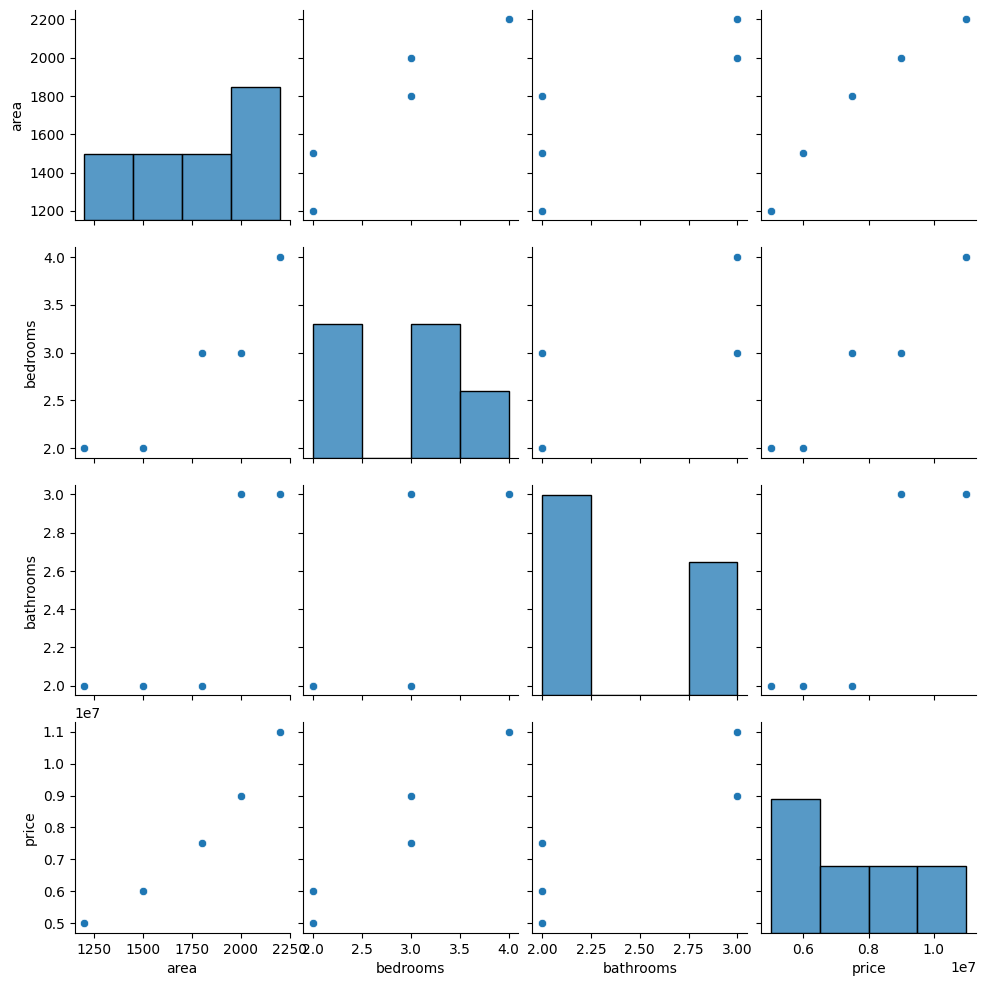

In [7]:
sns.pairplot(df)
plt.show()

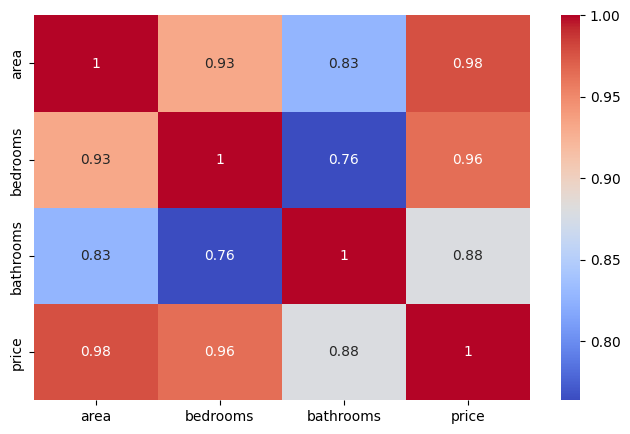

In [8]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

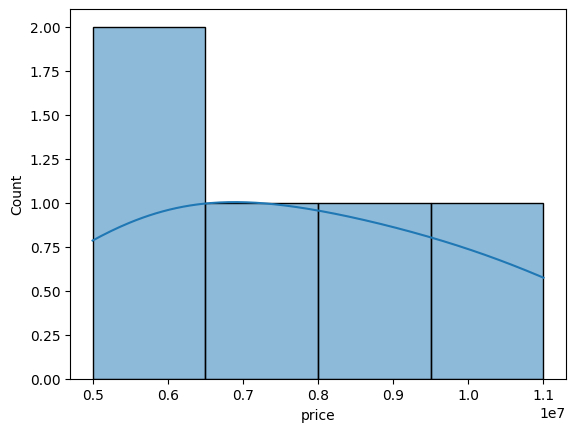

In [9]:
sns.histplot(df['price'], kde=True)
plt.show()

In [10]:
df.head()

,area,bedrooms,bathrooms,location,price
0,1200,2,2,urban,5000000
1,2000,3,3,urban,9000000
2,1500,2,2,suburban,6000000
3,1800,3,2,suburban,7500000
4,2200,4,3,urban,11000000


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['location'] = le.fit_transform(df['location'])

df.head()

,area,bedrooms,bathrooms,location,price
0,1200,2,2,1,5000000
1,2000,3,3,1,9000000
2,1500,2,2,0,6000000
3,1800,3,2,0,7500000
4,2200,4,3,1,11000000


In [12]:
X = df.drop('price', axis=1)  # features
y = df['price']               # target

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (4, 4)
X_test: (1, 4)


In [15]:
from sklearn.linear_model import LinearRegression


In [16]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [   5735.27724919 -220583.17475537  705889.10032618  720583.17475537]
Intercept: -3573527.7249282915


In [18]:
y_pred = model.predict(X_test)

In [19]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head()

,Actual,Predicted
1,9000000,1.007353e+07


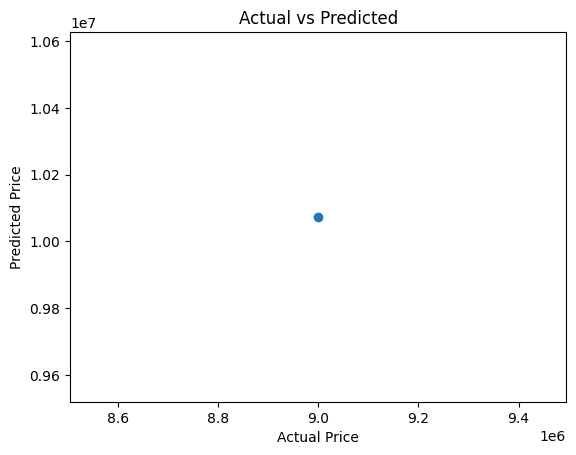

In [20]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [22]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1073527.724920364
MSE: 1152461776172.6929
RMSE: 1073527.724920364
R2 Score: nan


c:\Users\shiva\My files\Projects\House Price Prediction\venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [23]:
import pickle

In [24]:
with open("../models/model.pkl","wb") as f:
    pickle.dump(model, f)

In [25]:
with open("../models/model.pkl","rb") as f:
    loaded_model = pickle.load(f)

#test prediction
sample = X_test.iloc[0:1]
print("Prediction:",loaded_model.predict(sample))

Prediction: [10073527.72492036]
